In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo

# Load the UCI student dropout dataset
student_data = fetch_ucirepo(id=697)

X = student_data.data.features
y = student_data.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (4424, 36)
Target shape: (4424, 1)


In [3]:
print("First 5 rows of the features:")
display(X.head())

print("\nTarget values:")
display(y.head())

print("\nTarget classes:")
print(y.iloc[:, 0].value_counts())

First 5 rows of the features:


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79



Target values:


,Target
0,Dropout
1,Graduate
2,Dropout
3,Graduate
4,Graduate



Target classes:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [4]:
print(X.dtypes)

Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [5]:
print(y.columns)

Index(['Target'], dtype='object')


In [6]:
print(y['Target'].unique())

['Dropout' 'Graduate' 'Enrolled']


In [7]:
print("Number of students in each outcome:")
print(y["Target"].value_counts())

print("\nPercentage of each outcome:")
print((y["Target"].value_counts(normalize=True) * 100).round(2))

Number of students in each outcome:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Percentage of each outcome:
Target
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [8]:
print("Total missing values:", X.isnull().sum().sum())

print("\nMissing values by column:")
print(X.isnull().sum()[X.isnull().sum() > 0])

Total missing values: 0

Missing values by column:
Series([], dtype: int64)


In [9]:
from sklearn.preprocessing import LabelEncoder

# Convert the three outcome labels into numbers
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y["Target"])

print("Class mapping:")
for number, class_name in enumerate(label_encoder.classes_):
    print(number, "=", class_name)

Class mapping:
0 = Dropout
1 = Enrolled
2 = Graduate


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])

Training records: 3539
Testing records: 885


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data scaled successfully.")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training data scaled successfully.
Training shape: (3539, 36)
Testing shape: (885, 36)


In [12]:
from sklearn.svm import SVC

# Create and train the SVM model
svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train_scaled, y_train)

# Make predictions on unseen test data
svm_predictions = svm_model.predict(X_test_scaled)

print("SVM model trained successfully.")

SVM model trained successfully.


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Create and train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

# Make predictions on unseen test data
rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# SVM metrics
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions, average="weighted")
svm_recall = recall_score(y_test, svm_predictions, average="weighted")
svm_f1 = f1_score(y_test, svm_predictions, average="weighted")

# Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions, average="weighted")
rf_recall = recall_score(y_test, rf_predictions, average="weighted")
rf_f1 = f1_score(y_test, rf_predictions, average="weighted")

print("SVM")
print(f"Accuracy : {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall   : {svm_recall:.4f}")
print(f"F1-score : {svm_f1:.4f}")

print("\nRandom Forest")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")

SVM
Accuracy : 0.7582
Precision: 0.7465
Recall   : 0.7582
F1-score : 0.7454

Random Forest
Accuracy : 0.7684
Precision: 0.7548
Recall   : 0.7684
F1-score : 0.7542


In [15]:
from sklearn.metrics import classification_report

print("SVM Classification Report")
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=label_encoder.classes_
    )
)

print("\nRandom Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=label_encoder.classes_
    )
)

SVM Classification Report
              precision    recall  f1-score   support

     Dropout       0.84      0.73      0.78       284
    Enrolled       0.50      0.35      0.41       159
    Graduate       0.77      0.93      0.84       442

    accuracy                           0.76       885
   macro avg       0.71      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885


Random Forest Classification Report
              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.78       284
    Enrolled       0.56      0.36      0.44       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.75      0.77      0.75       885



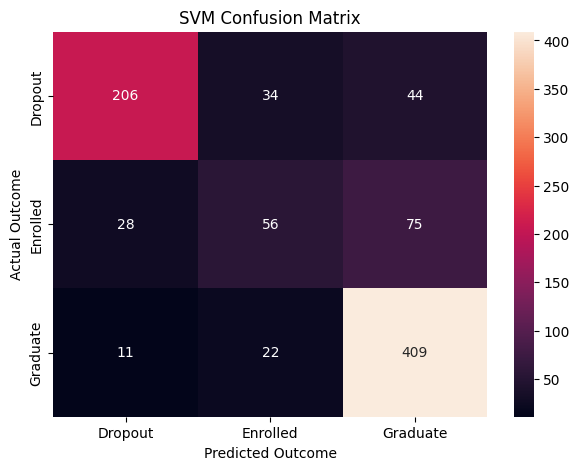

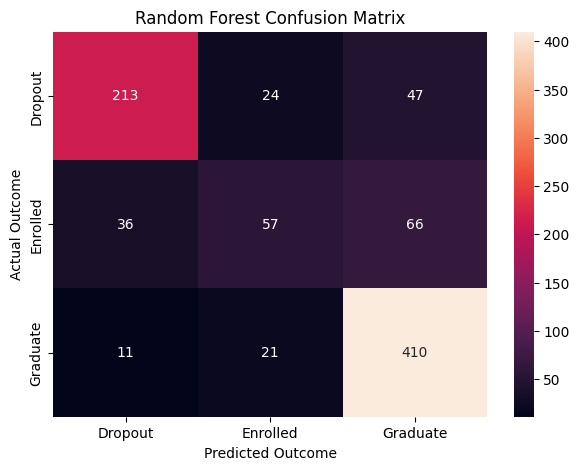

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

svm_cm = confusion_matrix(y_test, svm_predictions)
rf_cm = confusion_matrix(y_test, rf_predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.show()

In [17]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance.head(15))

                                   Feature  Importance
30     Curricular units 2nd sem (approved)    0.126016
31        Curricular units 2nd sem (grade)    0.093321
24     Curricular units 1st sem (approved)    0.067409
25        Curricular units 1st sem (grade)    0.065422
12                         Admission grade    0.047419
29  Curricular units 2nd sem (evaluations)    0.045668
19                       Age at enrollment    0.042926
6           Previous qualification (grade)    0.042507
23  Curricular units 1st sem (evaluations)    0.041072
16                 Tuition fees up to date    0.037364
3                                   Course    0.034524
11                     Father's occupation    0.033758
10                     Mother's occupation    0.030101
35                                     GDP    0.026760
33                       Unemployment rate    0.025555


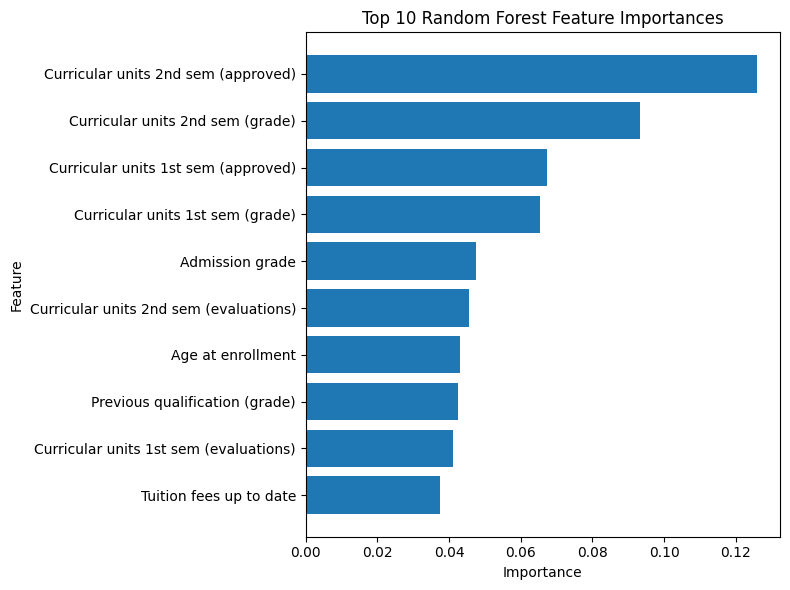

In [18]:
top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(8, 6))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [19]:
from ucimlrepo import fetch_ucirepo

# Load the UCI Student Performance dataset
student_performance = fetch_ucirepo(id=320)

X2 = student_performance.data.features
y2 = student_performance.data.targets

print("Features shape:", X2.shape)
print("Target shape:", y2.shape)

print("\nFeature columns:")
print(X2.columns.tolist())

print("\nTarget columns:")
print(y2.columns.tolist())

Features shape: (649, 30)
Target shape: (649, 3)

Feature columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Target columns:
['G1', 'G2', 'G3']


In [20]:
# Create a binary target using the final grade (G3)
y2_binary = (y2["G3"] >= 10).astype(int)

print("Student outcome distribution:")
print(y2_binary.value_counts())

print("\nPercentage distribution:")
print((y2_binary.value_counts(normalize=True) * 100).round(2))

Student outcome distribution:
G3
1    549
0    100
Name: count, dtype: int64

Percentage distribution:
G3
1    84.59
0    15.41
Name: proportion, dtype: float64


In [21]:
# Remove G1 and G2 because they are not part of the predictor variables
X2_processed = X2.copy()

# Convert categorical variables into numerical dummy variables
X2_processed = pd.get_dummies(
    X2_processed,
    drop_first=True
)

print("Processed feature shape:", X2_processed.shape)
print("\nFirst 5 rows:")
display(X2_processed.head())

Processed feature shape: (649, 39)

First 5 rows:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


In [22]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_processed,
    y2_binary,
    test_size=0.20,
    random_state=42,
    stratify=y2_binary
)

print("Training records:", X2_train.shape[0])
print("Testing records:", X2_test.shape[0])

Training records: 519
Testing records: 130


In [23]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

print("Dataset 2 scaling completed.")
print("Training shape:", X2_train_scaled.shape)
print("Testing shape:", X2_test_scaled.shape)

Dataset 2 scaling completed.
Training shape: (519, 39)
Testing shape: (130, 39)


In [24]:
svm_model2 = SVC(
    kernel="rbf",
    random_state=42,
    class_weight="balanced"
)

svm_model2.fit(X2_train_scaled, y2_train)

svm_predictions2 = svm_model2.predict(X2_test_scaled)

print("Dataset 2 SVM trained successfully.")

Dataset 2 SVM trained successfully.


In [25]:
rf_model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model2.fit(X2_train, y2_train)

rf_predictions2 = rf_model2.predict(X2_test)

print("Dataset 2 Random Forest trained successfully.")

Dataset 2 Random Forest trained successfully.


In [26]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# SVM results
svm2_accuracy = accuracy_score(y2_test, svm_predictions2)
svm2_precision = precision_score(y2_test, svm_predictions2)
svm2_recall = recall_score(y2_test, svm_predictions2)
svm2_f1 = f1_score(y2_test, svm_predictions2)

# Random Forest results
rf2_accuracy = accuracy_score(y2_test, rf_predictions2)
rf2_precision = precision_score(y2_test, rf_predictions2)
rf2_recall = recall_score(y2_test, rf_predictions2)
rf2_f1 = f1_score(y2_test, rf_predictions2)

print("Dataset 2 - SVM")
print(f"Accuracy : {svm2_accuracy:.4f}")
print(f"Precision: {svm2_precision:.4f}")
print(f"Recall   : {svm2_recall:.4f}")
print(f"F1-score : {svm2_f1:.4f}")

print("\nDataset 2 - Random Forest")
print(f"Accuracy : {rf2_accuracy:.4f}")
print(f"Precision: {rf2_precision:.4f}")
print(f"Recall   : {rf2_recall:.4f}")
print(f"F1-score : {rf2_f1:.4f}")

Dataset 2 - SVM
Accuracy : 0.7769
Precision: 0.9010
Recall   : 0.8273
F1-score : 0.8626

Dataset 2 - Random Forest
Accuracy : 0.8000
Precision: 0.8500
Recall   : 0.9273
F1-score : 0.8870


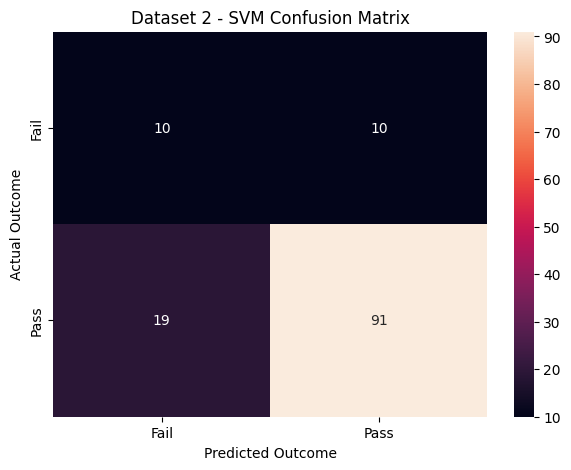

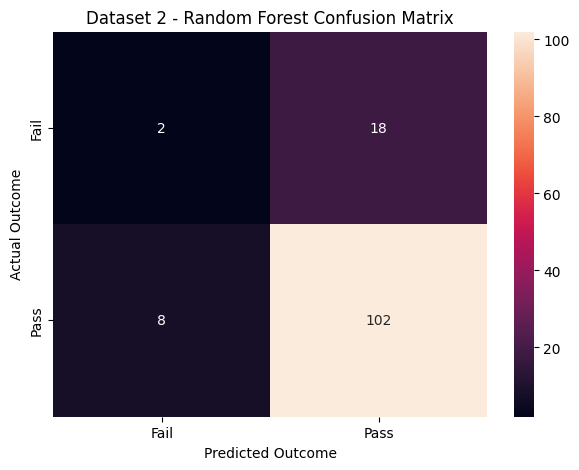

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

svm2_cm = confusion_matrix(y2_test, svm_predictions2)
rf2_cm = confusion_matrix(y2_test, rf_predictions2)

class_names = ["Fail", "Pass"]

plt.figure(figsize=(7, 5))
sns.heatmap(
    svm2_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Dataset 2 - SVM Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(
    rf2_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Dataset 2 - Random Forest Confusion Matrix")
plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")
plt.show()

In [28]:
feature_importance2 = pd.DataFrame({
    "Feature": X2_processed.columns,
    "Importance": rf_model2.feature_importances_
})

feature_importance2 = feature_importance2.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance2.head(15).to_string(index=False))

   Feature  Importance
  failures    0.119444
 school_MS    0.101221
higher_yes    0.068295
  absences    0.049025
      Fedu    0.046098
      Walc    0.045716
      Medu    0.043892
  freetime    0.040020
     goout    0.038891
    famrel    0.036561
 studytime    0.033664
       age    0.033496
      Dalc    0.031639
    health    0.026077
traveltime    0.025355


In [32]:
feature_importance2 = pd.DataFrame({
    "Feature": X2_processed.columns,
    "Importance": rf_model2.feature_importances_
})

feature_importance2 = feature_importance2.sort_values(
    "Importance",
    ascending=False
)

print(feature_importance2.head(15).to_string(index=False))

   Feature  Importance
  failures    0.119444
 school_MS    0.101221
higher_yes    0.068295
  absences    0.049025
      Fedu    0.046098
      Walc    0.045716
      Medu    0.043892
  freetime    0.040020
     goout    0.038891
    famrel    0.036561
 studytime    0.033664
       age    0.033496
      Dalc    0.031639
    health    0.026077
traveltime    0.025355
